# Regresión Lineal – Calidad del Aire (Ozono)
**Dataset:** `ad_viz_plotval_data.csv`  
**Estación:** Hermiston - Municipal Airport (HMA), Oregon, EE.UU.  
**Período:** Abril – Septiembre 2023  
**Variable objetivo:** `Daily AQI Value` (Índice de Calidad del Aire)

# Importamos Paquetes

In [ ]:
import numpy as np               # Cálculos numéricos y manejo de arreglos/matrices
import pandas as pd              # Manejo y organización de datos en DataFrames
import matplotlib.pyplot as plt  # Creación de gráficos y visualizaciones
import seaborn as sns            # Visualización estadística y gráficos

# Muestra los gráficos directamente dentro del notebook
%matplotlib inline

# Importar el conjunto de datos

In [ ]:
'''
Cargamos el dataset de monitoreo de calidad del aire.
Contiene mediciones diarias de Ozono (O₃) registradas en una estación
de Oregon, EE.UU., durante el período abril–septiembre 2023.
'''
df_raw = pd.read_csv('ad_viz_plotval_data.csv')  # Cargo el archivo CSV
df_raw.head()  # Muestro las primeras filas para comprobar los datos

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,04/19/2023,AQS,410591003,1,0.043,ppm,40,Hermiston - Municipal Airport (HMA),17,100.0,...,Ozone,87,25840,"Hermiston-Pendleton, OR",41,Oregon,59,Umatilla,45.828968,-119.262991
1,04/20/2023,AQS,410591003,1,0.048,ppm,44,Hermiston - Municipal Airport (HMA),17,100.0,...,Ozone,87,25840,"Hermiston-Pendleton, OR",41,Oregon,59,Umatilla,45.828968,-119.262991
2,04/21/2023,AQS,410591003,1,0.047,ppm,44,Hermiston - Municipal Airport (HMA),17,100.0,...,Ozone,87,25840,"Hermiston-Pendleton, OR",41,Oregon,59,Umatilla,45.828968,-119.262991
3,04/22/2023,AQS,410591003,1,0.045,ppm,42,Hermiston - Municipal Airport (HMA),13,76.0,...,Ozone,87,25840,"Hermiston-Pendleton, OR",41,Oregon,59,Umatilla,45.828968,-119.262991
4,04/23/2023,AQS,410591003,1,0.038,ppm,35,Hermiston - Municipal Airport (HMA),17,100.0,...,Ozone,87,25840,"Hermiston-Pendleton, OR",41,Oregon,59,Umatilla,45.828968,-119.262991


# Selección de variables relevantes

El dataset original tiene 21 columnas, muchas de ellas categóricas o identificadores.
Seleccionamos las columnas numéricas útiles para el modelo y las renombramos para mayor claridad.

In [ ]:
# Seleccionamos las columnas numéricas relevantes
df = df_raw[[
    'Daily Max 8-hour Ozone Concentration',  # Concentración máxima de Ozono (ppm) — predictor principal
    'Daily Obs Count',                        # Número de observaciones diarias — indicador de completitud
    'Percent Complete',                       # Porcentaje de datos completos en el día
    'Daily AQI Value'                         # Índice de Calidad del Aire — variable OBJETIVO
]].copy()

# Renombramos columnas para simplificar el trabajo
df.columns = ['Concentracion_Ozono', 'Obs_Diarias', 'Pct_Completo', 'AQI']

df.head()  # Verificamos la selección

,Concentracion_Ozono,Obs_Diarias,Pct_Completo,AQI
0,0.043,17,100.0,40
1,0.048,17,100.0,44
2,0.047,17,100.0,44
3,0.045,13,76.0,42
4,0.038,17,100.0,35


# Consultar información básica sobre el conjunto de datos

*info() >> da información detallada*

In [ ]:
df.info(verbose=True)  # Consulto la estructura, tipos de datos y valores no nulos del conjunto

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Concentracion_Ozono  158 non-null    float64
 1   Obs_Diarias          158 non-null    int64  
 2   Pct_Completo         158 non-null    float64
 3   AQI                  158 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 5.1 KB


*describe() >> resumen estadístico*

In [ ]:
df.describe().round(4)  # Obtengo un resumen estadístico de las variables numéricas

,Concentracion_Ozono,Obs_Diarias,Pct_Completo,AQI
count,158.0000,158.0000,158.0000,158.0000
mean,0.0464,16.9557,99.7342,44.5949
std,0.0091,0.3966,2.3794,11.6652
min,0.0150,13.0000,76.0000,14.0000
25%,0.0400,17.0000,100.0000,37.0000
50%,0.0470,17.0000,100.0000,44.0000
75%,0.0530,17.0000,100.0000,49.0000
max,0.0660,17.0000,100.0000,87.0000


In [ ]:
df.columns  # Consulto los nombres de las columnas del conjunto de datos

Index(['Concentracion_Ozono', 'Obs_Diarias', 'Pct_Completo', 'AQI'], dtype='object')

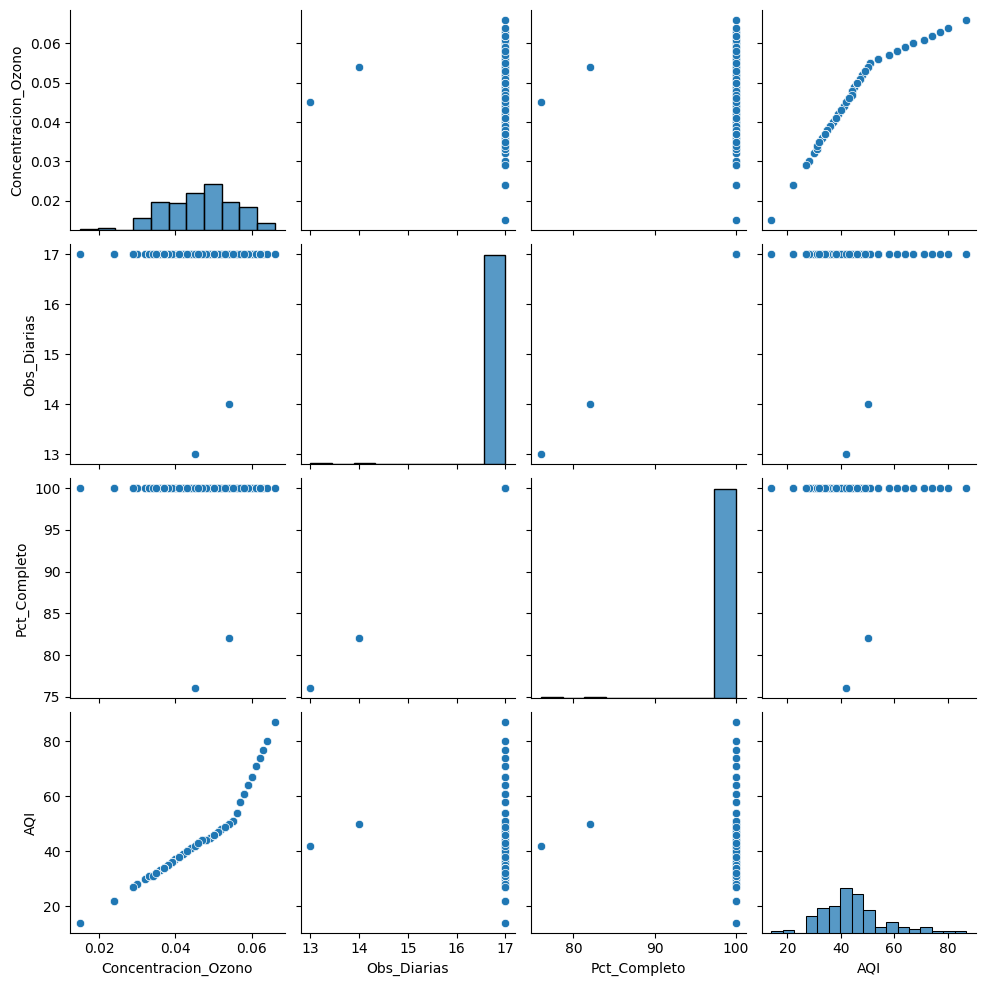

In [ ]:
sns.pairplot(df)  # Visualizo las relaciones entre todas las variables del conjunto de datos

# Distribución del Índice de Calidad del Aire (AQI)

Text(0, 0.5, 'Frecuencia')

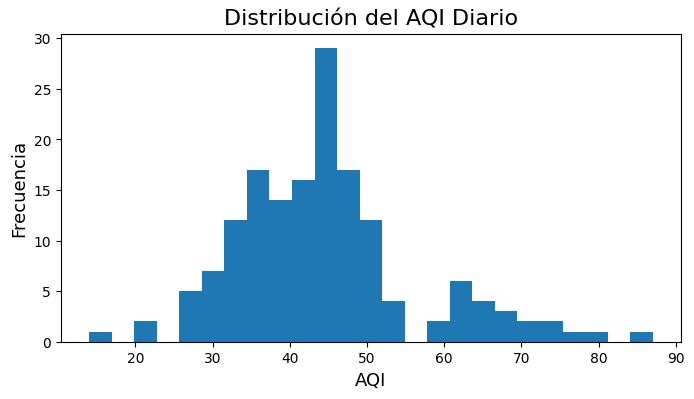

In [ ]:
df['AQI'].plot.hist(bins=25, figsize=(8, 4))  # Represento la distribución del AQI mediante un histograma
plt.title('Distribución del AQI Diario', fontsize=16)
plt.xlabel('AQI', fontsize=13)
plt.ylabel('Frecuencia', fontsize=13)

# Función de Densidad

Text(0.5, 0, 'AQI')

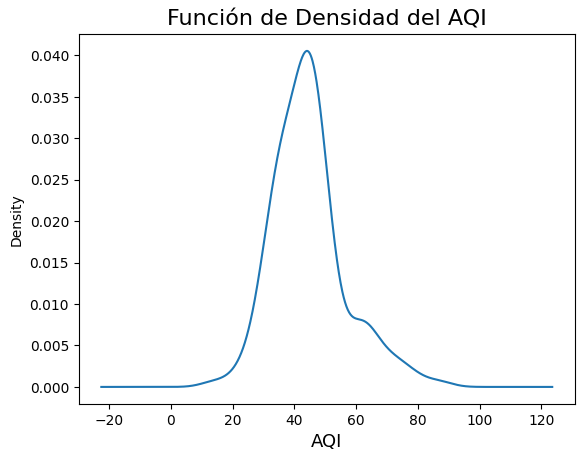

In [ ]:
df['AQI'].plot.density()  # Represento la función de densidad del AQI
plt.title('Función de Densidad del AQI', fontsize=16)
plt.xlabel('AQI', fontsize=13)

# Matriz de correlación y Heatmap

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])  # Selecciono únicamente las columnas numéricas
numeric_df.corr().round(4)  # Calculo la matriz de correlación entre las variables numéricas

,Concentracion_Ozono,Obs_Diarias,Pct_Completo,AQI
Concentracion_Ozono,1.0000,-0.0302,-0.0302,0.9503
Obs_Diarias,-0.0302,1.0000,1.0000,-0.0080
Pct_Completo,-0.0302,1.0000,1.0000,-0.0080
AQI,0.9503,-0.0080,-0.0080,1.0000


Text(0.5, 1.0, 'Mapa de Calor – Correlaciones')

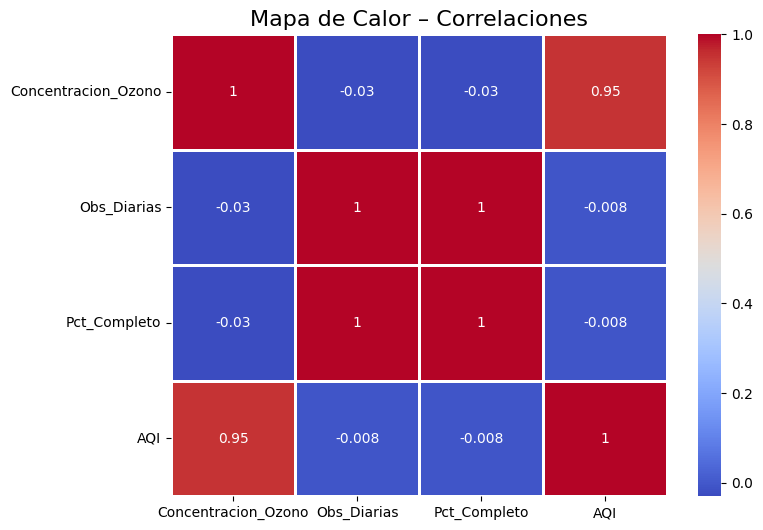

In [ ]:
plt.figure(figsize=(8, 6))  # Defino el tamaño de la figura
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2, cmap='coolwarm')  # Muestro la matriz de correlación con mapa de calor
plt.title('Mapa de Calor – Correlaciones', fontsize=16)

# Conjunto de características y variable objetivo

In [ ]:
l_column = list(df.columns)        # Guardo en una lista los nombres de las columnas
len_feature = len(l_column)        # Calculo la cantidad de características y variables
l_column                           # Muestro los nombres de las columnas

['Concentracion_Ozono', 'Obs_Diarias', 'Pct_Completo', 'AQI']

# Regresión Lineal

In [ ]:
x = df[l_column[0:len_feature-1]]  # Selecciono las variables predictoras (todas menos la última)
y = df[l_column[len_feature-1]]    # Selecciono AQI como variable objetivo
x.head()                           # Muestro las primeras filas de las variables predictoras

,Concentracion_Ozono,Obs_Diarias,Pct_Completo
0,0.043,17,100.0
1,0.048,17,100.0
2,0.047,17,100.0
3,0.045,13,76.0
4,0.038,17,100.0


In [ ]:
y.head()  # Muestro las primeras observaciones de la variable objetivo

,AQI
0,40
1,44
2,44
3,42
4,35


## Definimos entrenamiento – prueba

In [ ]:
from sklearn.model_selection import train_test_split  # Importo la función para dividir los datos

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(  # Divido variables predictoras y objetivo en entrenamiento y prueba
    x, y, test_size=0.3, random_state=123             # 70% entrenamiento, 30% prueba; semilla fija para reproducibilidad
)

# Ajuste y entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LinearRegression  # Importo el modelo de regresión lineal
from sklearn import metrics                        # Importo métricas para evaluar el modelo

In [ ]:
lm = LinearRegression()  # Creo una instancia del modelo de regresión lineal

In [ ]:
lm.fit(x_train, y_train)  # Entreno el modelo con los datos de entrenamiento

LinearRegression()

In [ ]:
print('El término de intersección del modelo lineal:', lm.intercept_)  # Muestro el intercepto del modelo

El término de intersección del modelo lineal: -15.623800781887674


In [ ]:
print('Coeficientes del modelo lineal:', lm.coef_)  # Muestro los coeficientes estimados

Coeficientes del modelo lineal: [1.21221012e+03 6.55510761e-03 3.93306457e-02]


In [ ]:
cdf = pd.DataFrame(data=lm.coef_, index=x_train.columns, columns=['coefficients'])  # Organizo los coeficientes con el nombre de cada variable
cdf  # Muestro el DataFrame con los coeficientes

,coefficients
Concentracion_Ozono,1212.210118
Obs_Diarias,0.006555
Pct_Completo,0.039331


# Cálculo de errores estándar y estadística t para los coeficientes

In [ ]:
'''
Calculo el error estándar y la estadística t de cada coeficiente.
Estos valores permiten evaluar la significancia estadística de cada variable predictora.
'''
n = x_train.shape[0]          # Cantidad de datos de entrenamiento
k = x_train.shape[1]          # Cantidad de variables predictoras
dfN = n - k                    # Grados de libertad

train_pred = lm.predict(x_train)  # Predicciones sobre el conjunto de entrenamiento

# Calculamos el error cuadrático
train_error = np.square(train_pred - y_train)  # (predicción - valor real)²
sum_error = np.sum(train_error)                # Suma total de errores cuadráticos

se = [0] * k  # Lista para almacenar los errores estándar de cada coeficiente
for i in range(k):  # Recorremos cada variable predictora
    r = (sum_error / dfN)  # Error promedio ponderado por los grados de libertad
    r = r / np.sum(np.square(
        x_train[list(x_train.columns)[i]] - x_train[list(x_train.columns)[i]].mean()
    ))  # Relacionamos el error con la variación de cada variable predictora
    se[i] = np.sqrt(r)  # Error estándar del coeficiente i

cdf['Standard Error'] = se                              # Agrego los errores estándar al DataFrame
cdf['t-statistic'] = cdf['coefficients'] / cdf['Standard Error']  # Estadística t: coeficiente / error estándar
# Un t-statistic alto (en valor absoluto) indica que la variable tiene un efecto significativo
cdf

,coefficients,Standard Error,t-statistic
Concentracion_Ozono,1212.210118,39.193945,30.928504
Obs_Diarias,0.006555,0.958513,0.006839
Pct_Completo,0.039331,0.159752,0.246198


# Gráficos de dispersión: predictores vs. AQI

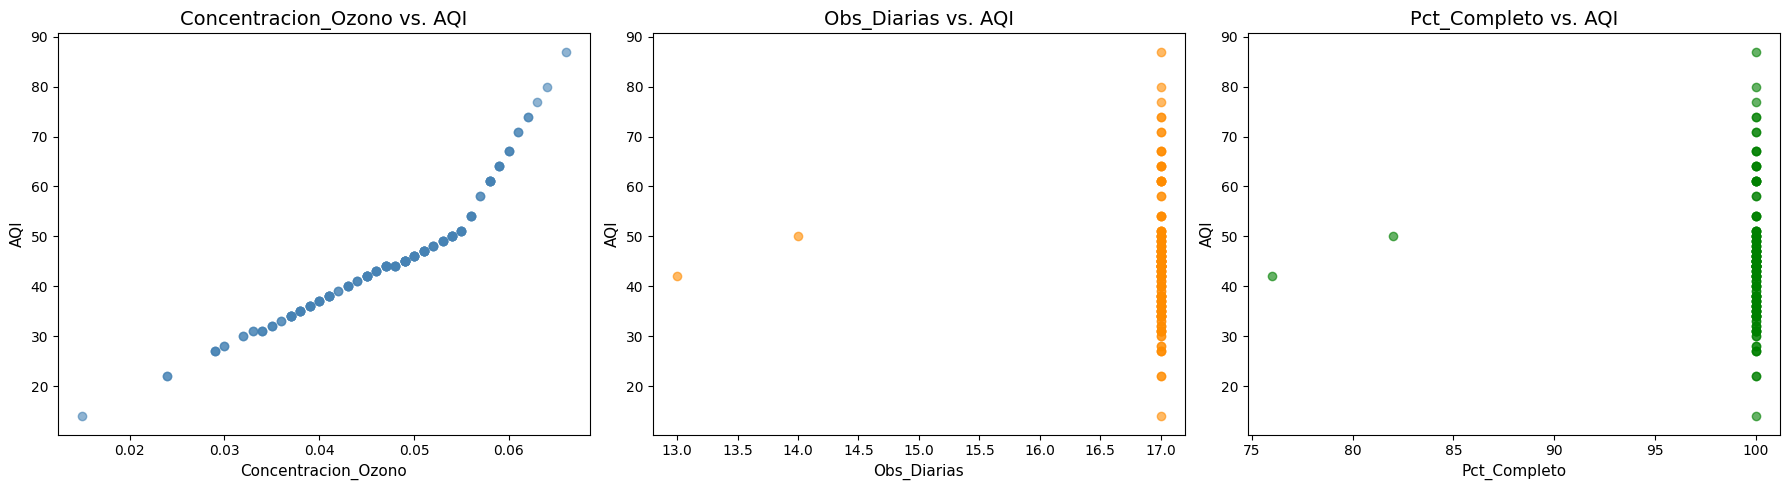

In [ ]:
l = list(cdf.index)  # Nombres de las variables predictoras

from matplotlib import gridspec  # Herramienta para organizar múltiples subgráficos
fig = plt.figure(figsize=(18, 5))  # Figura de gran tamaño
gs = gridspec.GridSpec(1, 3)       # Una fila con 3 columnas (una por cada predictor)

ax0 = plt.subplot(gs[0])  # Primer gráfico
ax0.scatter(df[l[0]], df['AQI'], color='steelblue', alpha=0.6)  # Concentración de Ozono vs AQI
ax0.set_title(l[0] + ' vs. AQI', fontdict={'fontsize': 14})
ax0.set_xlabel(l[0], fontsize=11)
ax0.set_ylabel('AQI', fontsize=11)

ax1 = plt.subplot(gs[1])  # Segundo gráfico
ax1.scatter(df[l[1]], df['AQI'], color='darkorange', alpha=0.6)  # Observaciones diarias vs AQI
ax1.set_title(l[1] + ' vs. AQI', fontdict={'fontsize': 14})
ax1.set_xlabel(l[1], fontsize=11)
ax1.set_ylabel('AQI', fontsize=11)

ax2 = plt.subplot(gs[2])  # Tercer gráfico
ax2.scatter(df[l[2]], df['AQI'], color='green', alpha=0.6)  # Porcentaje completo vs AQI
ax2.set_title(l[2] + ' vs. AQI', fontdict={'fontsize': 14})
ax2.set_xlabel(l[2], fontsize=11)
ax2.set_ylabel('AQI', fontsize=11)

plt.tight_layout()

# Matrices de predicción

In [ ]:
predictions = lm.predict(x_test)  # Realizo predicciones utilizando los datos de prueba
print('Tipo del objeto predicho:', type(predictions))       # Tipo del objeto
print('Tamaño del objeto predicho:', predictions.shape)    # Cantidad de predicciones

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (48,)


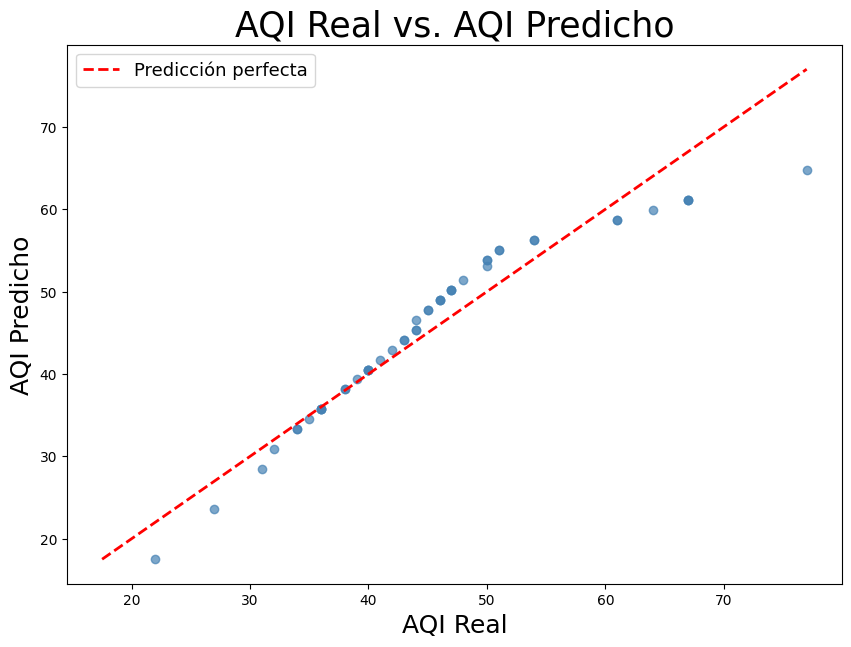

In [ ]:
# Diagrama de dispersión: AQI real vs. AQI predicho
'''
Meta: los puntos deben caer sobre una línea recta de 45°,
lo que indicaría predicciones perfectas.
'''
plt.figure(figsize=(10, 7))                                    # Tamaño de la figura
plt.title('AQI Real vs. AQI Predicho', fontsize=25)           # Título
plt.xlabel('AQI Real', fontsize=18)                           # Eje horizontal
plt.ylabel('AQI Predicho', fontsize=18)                       # Eje vertical
plt.scatter(x=y_test, y=predictions, color='steelblue', alpha=0.7)  # Comparación visual

# Línea de referencia perfecta (45°)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
plt.legend(fontsize=13)

<Axes: title={'center': 'Histograma de Residuos\n(Verificación de Normalidad)'}, xlabel='Residuos', ylabel='Densidad del kernel'>

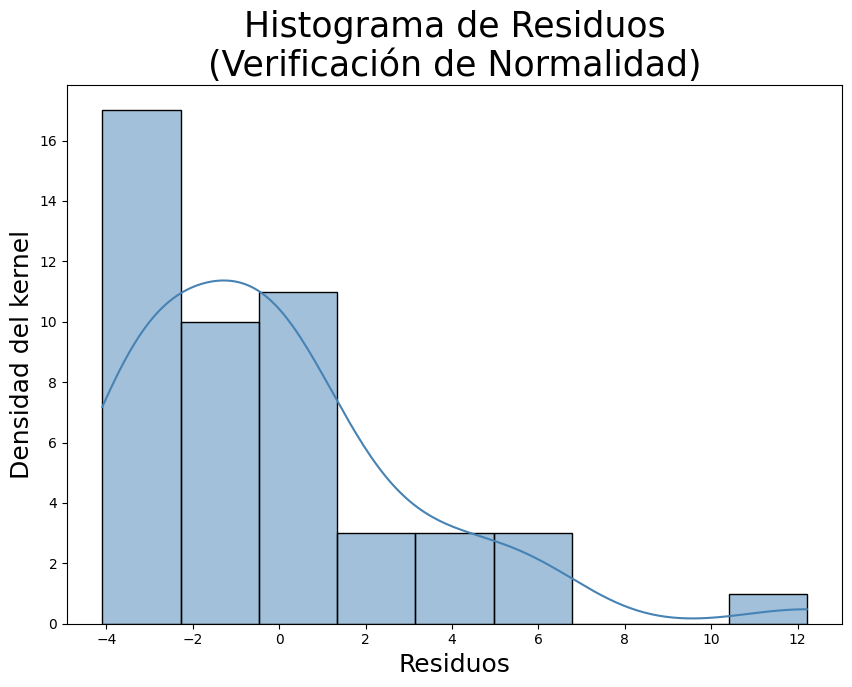

In [ ]:
# Histograma de residuos para verificar normalidad
plt.figure(figsize=(10, 7))                                       # Tamaño de la figura
plt.title('Histograma de Residuos\n(Verificación de Normalidad)', fontsize=25)  # Título
plt.xlabel('Residuos', fontsize=18)                              # Eje horizontal
plt.ylabel('Densidad del kernel', fontsize=18)                   # Eje vertical
residuos = y_test - predictions
sns.histplot(residuos, kde=True, color='steelblue')              # Histograma con curva de densidad
# Si los residuos siguen una distribución aproximadamente normal, el modelo es adecuado

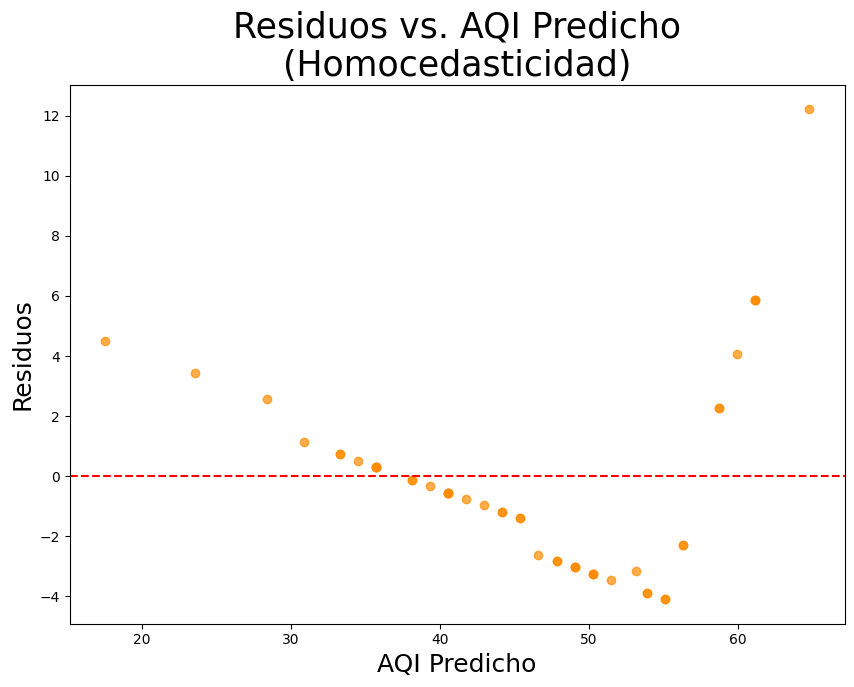

In [ ]:
'''
Análisis de residuos vs. valores predichos (Homocedasticidad).
Si los errores se distribuyen de forma constante a lo largo de las predicciones,
el modelo cumple el supuesto de varianza constante.
'''
plt.figure(figsize=(10, 7))                                      # Tamaño de la figura
plt.title('Residuos vs. AQI Predicho\n(Homocedasticidad)', fontsize=25)  # Título
plt.xlabel('AQI Predicho', fontsize=18)                         # Eje horizontal
plt.ylabel('Residuos', fontsize=18)                             # Eje vertical
plt.scatter(x=predictions, y=residuos, color='darkorange', alpha=0.7)  # Residuos vs predicciones
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)   # Línea de referencia en cero

# Métricas de evaluación del modelo

In [ ]:
mae  = metrics.mean_absolute_error(y_test, predictions)   # Error Absoluto Medio
mse  = metrics.mean_squared_error(y_test, predictions)    # Error Cuadrático Medio
rmse = np.sqrt(mse)                                        # Raíz del Error Cuadrático Medio
r2   = metrics.r2_score(y_test, predictions)               # Coeficiente de determinación R²

print(f'MAE  (Error Absoluto Medio):              {mae:.4f}')
print(f'MSE  (Error Cuadrático Medio):            {mse:.4f}')
print(f'RMSE (Raíz del Error Cuadrático Medio):   {rmse:.4f}')
print(f'R²   (Coeficiente de determinación):      {r2:.4f}')
# R² cercano a 1 indica que el modelo explica bien la variabilidad del AQI

MAE  (Error Absoluto Medio):              2.4384
MSE  (Error Cuadrático Medio):            10.5707
RMSE (Raíz del Error Cuadrático Medio):   3.2513
R²   (Coeficiente de determinación):      0.9130


# Random Forest

Comparamos el modelo de regresión lineal con un **Random Forest Regressor**,
un modelo de ensamble más potente que puede capturar relaciones no lineales.

In [ ]:
import matplotlib.pyplot as plt   # Reimportamos para claridad
%matplotlib inline
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor  # Importo el modelo Random Forest
from sklearn.model_selection import train_test_split

In [ ]:
# Usamos las mismas divisiones de entrenamiento y prueba definidas anteriormente
rf = RandomForestRegressor(n_estimators=100, random_state=123)  # 100 árboles, semilla fija
rf.fit(x_train, y_train)                                        # Entreno el modelo Random Forest

RandomForestRegressor(random_state=123)

In [ ]:
rf_predictions = rf.predict(x_test)  # Predicciones del Random Forest sobre el conjunto de prueba

# Métricas del Random Forest
rf_mae  = metrics.mean_absolute_error(y_test, rf_predictions)
rf_mse  = metrics.mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = metrics.r2_score(y_test, rf_predictions)

print('=== Random Forest ===' )
print(f'MAE  : {rf_mae:.4f}')
print(f'MSE  : {rf_mse:.4f}')
print(f'RMSE : {rf_rmse:.4f}')
print(f'R²   : {rf_r2:.4f}')

=== Random Forest ===
MAE  : 0.3481
MSE  : 0.7163
RMSE : 0.8464
R²   : 0.9941


# Importancia de variables (Random Forest)

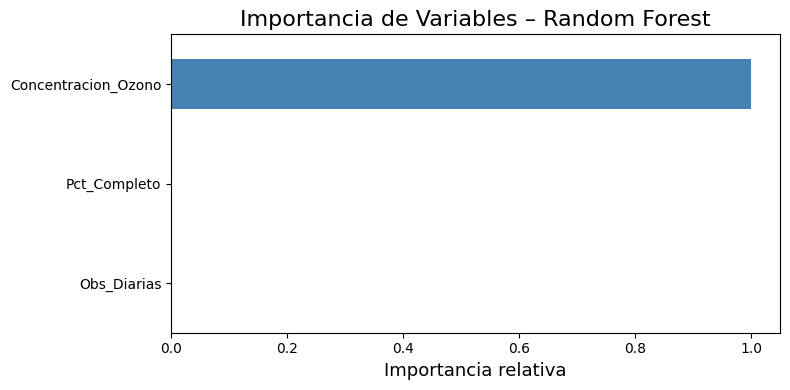

In [ ]:
# El Random Forest permite calcular qué tanto contribuye cada variable predictora
importancias = pd.Series(rf.feature_importances_, index=x_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancias.plot.barh(color='steelblue')  # Gráfico de barras horizontal de importancias
plt.title('Importancia de Variables – Random Forest', fontsize=16)
plt.xlabel('Importancia relativa', fontsize=13)
plt.tight_layout()

# Comparación final: Regresión Lineal vs. Random Forest

In [ ]:
# Tabla comparativa de métricas
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'MAE':  [round(mae, 4),    round(rf_mae, 4)],
    'RMSE': [round(rmse, 4),   round(rf_rmse, 4)],
    'R²':   [round(r2, 4),     round(rf_r2, 4)]
})
comparacion  # El modelo con R² más alto y RMSE más bajo es el mejor ajuste

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,2.4384,3.2513,0.9130
1,Random Forest,0.3481,0.8464,0.9941


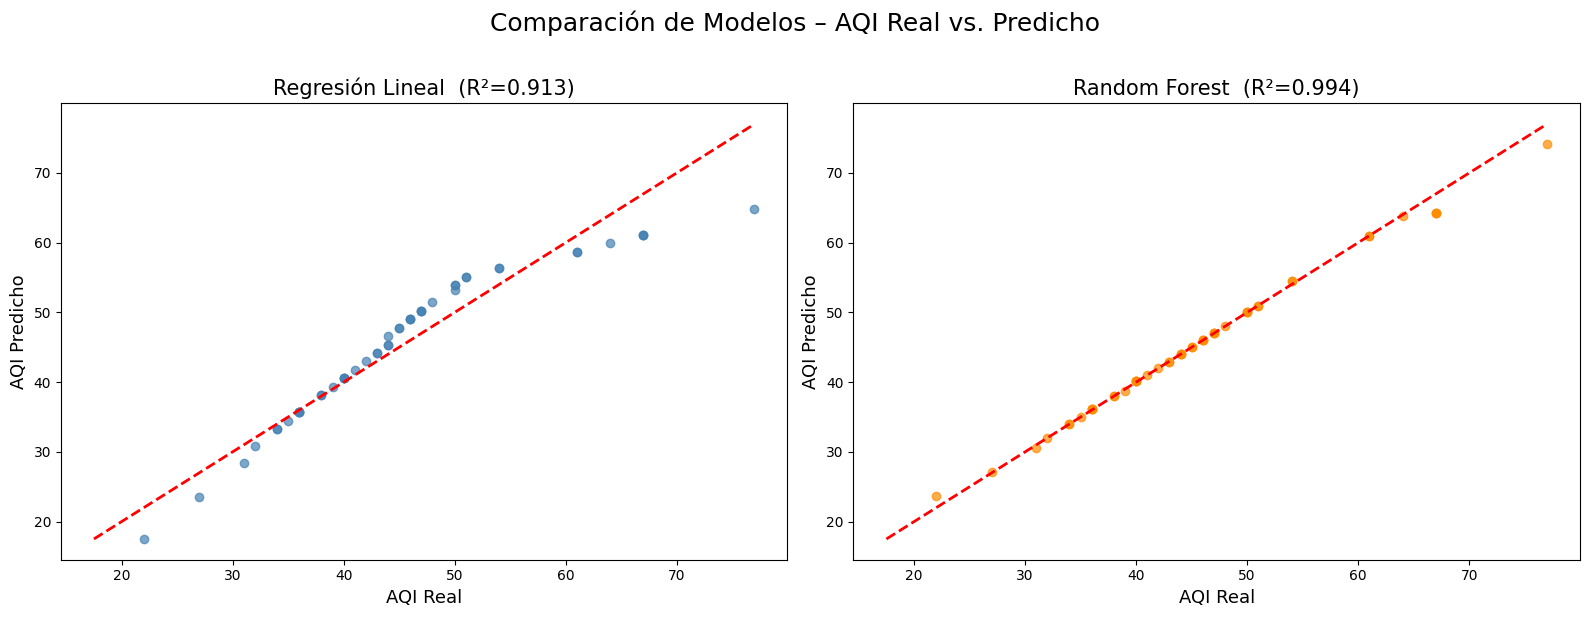

In [ ]:
# Visualización comparativa: AQI real vs predicciones de ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Dos gráficos en paralelo

lims = [min(y_test.min(), predictions.min(), rf_predictions.min()),
        max(y_test.max(), predictions.max(), rf_predictions.max())]

# Regresión Lineal
axes[0].scatter(y_test, predictions, alpha=0.7, color='steelblue')
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_title(f'Regresión Lineal  (R²={r2:.3f})', fontsize=15)
axes[0].set_xlabel('AQI Real', fontsize=13)
axes[0].set_ylabel('AQI Predicho', fontsize=13)

# Random Forest
axes[1].scatter(y_test, rf_predictions, alpha=0.7, color='darkorange')
axes[1].plot(lims, lims, 'r--', linewidth=2)
axes[1].set_title(f'Random Forest  (R²={rf_r2:.3f})', fontsize=15)
axes[1].set_xlabel('AQI Real', fontsize=13)
axes[1].set_ylabel('AQI Predicho', fontsize=13)

plt.suptitle('Comparación de Modelos – AQI Real vs. Predicho', fontsize=18, y=1.02)
plt.tight_layout()

In [72]:
import statsmodels.api as sm  # Importo Statsmodels para realizar el análisis estadístico OLS

In [73]:

# Usamos x_train y y_train para ser consistentes con la evaluación del modelo original
Xs = sm.add_constant(x_train)    # Agrego una constante al conjunto de variables predictoras de entrenamiento
stat_model = sm.OLS(y_train, Xs) # Creo el modelo de Mínimos Cuadrados Ordinarios
stat_result = stat_model.fit()   # Ajusto el modelo OLS a los datos
print(stat_result.summary())     # Muestro el resumen estadístico completo del modelo

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     478.4
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           4.31e-54
Time:                        21:22:41   Log-Likelihood:                -301.89
No. Observations:                 110   AIC:                             609.8
Df Residuals:                     107   BIC:                             617.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -14.0995    

/tmp/ipykernel_1872/2458736100.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  stat_result = stat_model.fit()   # Ajusto el modelo OLS a los datos
